# Exploratory Data Analysis

In [1]:
# NLP Analysis:
from sklearn.feature_extraction.text import TfidfVectorizer
import nltk
nltk.download('vader_lexicon')
from nltk.sentiment import SentimentIntensityAnalyzer

# Data exploration:
import pandas as pd
import numpy as np

# Data Visualization:
import matplotlib.pyplot as plt

# Parallelization: Use all CPU cores: 
from joblib import Parallel, delayed

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /home/its30na/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [3]:
df = pd.read_csv('../data/raw/berlin_reviews_clean.csv')
df

,title,url,cuisines,reviews,star rating,page number,data offset,restaurant,dates,dates_parsed,earliest_date,latest_date,review_count,review_period_days,language,clean_reviews
0,1. Focaccino,https://www.tripadvisor.in/Restaurant_Review-g...,"Italian, Sicilian",The atmosphere is very classy yet cozy. The ow...,4.5 of 5 bubbles,0,0,1,"['13 November 2023', '23 September 2023', '28 ...","[Timestamp('2023-11-13 00:00:00'), Timestamp('...",2011-08-19,2023-11-13,202,4469.0,en,atmosphere classy yet cozy owner gracious repr...
1,1. Focaccino,https://www.tripadvisor.in/Restaurant_Review-g...,"Italian, Sicilian",Ricardo took excellent are of us last night. H...,4.5 of 5 bubbles,0,0,1,"['13 November 2023', '23 September 2023', '28 ...","[Timestamp('2023-11-13 00:00:00'), Timestamp('...",2011-08-19,2023-11-13,202,4469.0,en,ricardo took excellent us last night picked wi...
2,1. Focaccino,https://www.tripadvisor.in/Restaurant_Review-g...,"Italian, Sicilian",Best copanata I ever had !! Every dish we orde...,4.5 of 5 bubbles,0,0,1,"['13 November 2023', '23 September 2023', '28 ...","[Timestamp('2023-11-13 00:00:00'), Timestamp('...",2011-08-19,2023-11-13,202,4469.0,en,best copanata ever every dish ordered cooked p...
3,1. Focaccino,https://www.tripadvisor.in/Restaurant_Review-g...,"Italian, Sicilian",This is now our favorite restaurant in Berlin....,4.5 of 5 bubbles,0,0,1,"['13 November 2023', '23 September 2023', '28 ...","[Timestamp('2023-11-13 00:00:00'), Timestamp('...",2011-08-19,2023-11-13,202,4469.0,en,favorite restaurant berlin loved everything am...
4,1. Focaccino,https://www.tripadvisor.in/Restaurant_Review-g...,"Italian, Sicilian","Absolutely delicious food, great host, great w...",4.5 of 5 bubbles,0,0,1,"['13 November 2023', '23 September 2023', '28 ...","[Timestamp('2023-11-13 00:00:00'), Timestamp('...",2011-08-19,2023-11-13,202,4469.0,en,absolutely delicious food great host great win...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
143613,5637. Cancun,https://www.tripadvisor.in/Restaurant_Review-g...,"Mexican, Latin",If a famine ever breaks out and cacun is the o...,2.5 of 5 bubbles,187,5610,5637,"['20 October 2023', '21 September 2023', '18 S...","[Timestamp('2023-10-20 00:00:00'), Timestamp('...",2012-07-23,2023-10-20,197,4106.0,en,famine ever breaks cacun restaurant left earth...
143614,5637. Cancun,https://www.tripadvisor.in/Restaurant_Review-g...,"Mexican, Latin",It was the first time we had Mexican food. We ...,2.5 of 5 bubbles,187,5610,5637,"['20 October 2023', '21 September 2023', '18 S...","[Timestamp('2023-10-20 00:00:00'), Timestamp('...",2012-07-23,2023-10-20,197,4106.0,en,first time mexican food ordered meal combinati...
143615,5639. Fame Burger,https://www.tripadvisor.in/Restaurant_Review-g...,"American, Grill","Fast fresh and big we will order again, we ord...",2.0 of 5 bubbles,187,5610,5639,['16 May 2021'],[Timestamp('2021-05-16 00:00:00')],2021-05-16,2021-05-16,1,0.0,en,fast fresh big order order one bowl one vegan ...
143616,5640. BackWerk,https://www.tripadvisor.in/Restaurant_Review-g...,NaN,Very unfriendly personnel. You cant expect muc...,1.0 of 5 bubbles,187,5610,5640,['19 October 2021'],[Timestamp('2021-10-19 00:00:00')],2021-10-19,2021-10-19,1,0.0,en,unfriendly personnel cant expect much train st...


In [4]:
df.shape

(143618, 16)

In [5]:
# Looking at the star ratings, we have more than 94% of the reviews with review scores > 3.0
# That means that about maximum 6% of the reviews are either critical or have a critic aspect in them, which could be good to know.
# Meanwhile ~21% of reviews are less-than-strongly-positive, being the ones with less than 4 stars.
round(df["star rating"].value_counts(normalize = True),6)

star rating
4.0 of 5 bubbles    0.410564
4.5 of 5 bubbles    0.359254
3.5 of 5 bubbles    0.157941
3.0 of 5 bubbles    0.043922
5.0 of 5 bubbles    0.023521
2.5 of 5 bubbles    0.004630
2.0 of 5 bubbles    0.000077
1.0 of 5 bubbles    0.000077
1.5 of 5 bubbles    0.000014
Name: proportion, dtype: float64

The distribution of star ratings reveals a strong positive skew in the dataset. 

Approximately 95% of reviews have ratings above 3.0, while only about 5% fall at or below 3 stars.
The majority of reviews are concentrated in the 4.0 (41.1%) and 4.5 (35.9%) categories, indicating generally high customer satisfaction. 
Reviews below 4.0 stars account for roughly 21% of the data, suggesting a smaller proportion of moderately positive or mixed experiences. 

However, it is important to note that lower ratings do not fully capture negative sentiment, as even highly rated reviews may contain critical feedback. This imbalance toward positive ratings should be considered in downstream tasks such as sentiment analysis or predictive modeling, as it may bias models toward overpredicting positive outcomes.

### My Verdict: Three possible routes for analyzing the cleaned dataset further:
1. Aspect-Based Sentiment Analysis
2. Sentiment classification
3. Restaurant ranking / insights

In [131]:
# Group reviews per Restaurant:
restaurant_texts = df.groupby(
    ["restaurant", "title"]
)["clean_reviews"].apply(lambda x: " ".join(x.dropna().astype(str))).reset_index()

In [132]:
restaurant_texts = restaurant_texts.rename(columns={
    "clean_reviews": "all_reviews"
})

In [133]:
restaurant_texts

,restaurant,title,all_reviews
0,1,1. Focaccino,atmosphere classy yet cozy owner gracious repr...
1,2,2. Cafe Couscous - Vege,best wraps berlin period suggest getting cousc...
2,3,3. Hackethals,found place tripadvisor wanted give try locate...
3,4,4. Restaurant Buschbeck's,wife coeliac research places could eat going b...
4,5,5. 100 Gramm Bar,place amaizing loved vibe music staff drinks c...
...,...,...,...
4380,5636,5636. PizzaBulls Deutschland,worst expereince ever customer service poor fo...
4381,5637,5637. Cancun,also good food vegetarians pay cash keep money...
4382,5639,5639. Fame Burger,fast fresh big order order one bowl one vegan ...
4383,5640,5640. BackWerk,unfriendly personnel cant expect much train st...


## 1. Aspect-Based Sentiment Analysis

In [175]:
# Getting TF Idf
ectorizer = TfidfVectorizer(
    max_features=5000,
    max_df=0.8,   # remove very common words
    min_df=5      # remove rare words
)
X = vectorizer.fit_transform(restaurant_texts["all_reviews"])

In [176]:
feature_names = vectorizer.get_feature_names_out()

In [177]:
feature_names

array(['ability', 'able', 'abroad', ..., 'zucchini', 'zum', 'zur'],
      shape=(5000,), dtype=object)

In [178]:
import numpy as np

def get_top_words(row, top_n=10):
    row_array = row.toarray().flatten()
    top_indices = np.argsort(row_array)[-top_n:][::-1]
    return [feature_names[i] for i in top_indices]

top_words_per_restaurant = [
    get_top_words(X[i], 10) for i in range(X.shape[0])
]

In [179]:
results = pd.DataFrame({
    "title": restaurant_texts.title,
    "restaurant": restaurant_texts.index+1,
    "top_words": top_words_per_restaurant
})

In [180]:
results["top_words"] = results["top_words"].apply(lambda x: ", ".join(x))

In [181]:
results

,title,restaurant,top_words
0,1. Focaccino,1,"italian, food, owner, restaurant, sicilian, pa..."
1,2. Cafe Couscous - Vege,2,"couscous, wraps, owner, falafel, fresh, hallou..."
2,3. Hackethals,3,"hackethals, food, german, beer, menu, restaura..."
3,4. Restaurant Buschbeck's,4,"food, restaurant, service, delicious, berlin, ..."
4,5. 100 Gramm Bar,5,"cocktails, drinks, bar, good, great, cool, atm..."
...,...,...,...
4380,5636. PizzaBulls Deutschland,4381,"delivery, pizza, mexico, worst, hade, fly, nea..."
4381,5637. Cancun,4382,"mexican, food, service, waiter, us, good, rest..."
4382,5639. Fame Burger,4383,"one, order, bowl, burger, favorite, vegan, fas..."
4383,5640. BackWerk,4384,"select, cant, personnel, train, unfriendly, st..."


**Now i can say:**

“Restaurant 1 is mostely associated respectively with italian, food, owner, restaurant, sicilian, pasta...”

“Restaurant 2 is mostely associated respectively with couscous, wraps, owner, falafel, fresh, halloummi...”

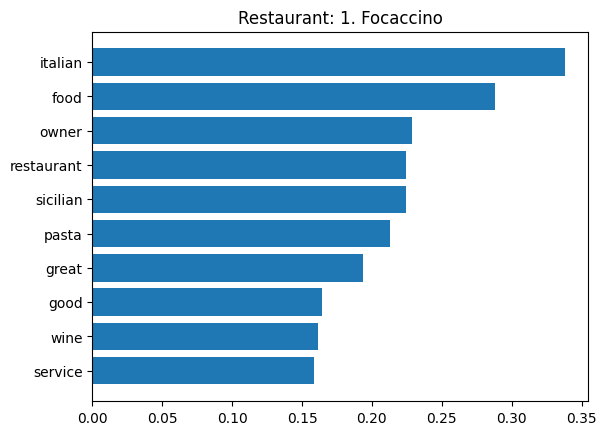

In [182]:
row = X[0].toarray().flatten()
top_indices = np.argsort(row)[-10:]

plt.barh(
    [feature_names[i] for i in top_indices],
    row[top_indices]
)
plt.title("Restaurant: " + restaurant_texts.title[0])
plt.show()

### I will now use VADER, a simple tool for this purpose:

In [183]:
sia = SentimentIntensityAnalyzer()

df["sentiment_score"] = df["reviews"].apply(lambda x: sia.polarity_scores(x)["compound"])

In [186]:
df.head()

,title,url,cuisines,reviews,star rating,page number,data offset,restaurant,dates,dates_parsed,earliest_date,latest_date,review_count,review_period_days,language,clean_reviews,sentiment_score
0,1. Focaccino,https://www.tripadvisor.in/Restaurant_Review-g...,"Italian, Sicilian",The atmosphere is very classy yet cozy. The ow...,4.5 of 5 bubbles,0,0,1,"['13 November 2023', '23 September 2023', '28 ...","[Timestamp('2023-11-13 00:00:00'), Timestamp('...",2011-08-19,2023-11-13,202,4469.0,en,atmosphere classy yet cozy owner gracious repr...,0.9693
1,1. Focaccino,https://www.tripadvisor.in/Restaurant_Review-g...,"Italian, Sicilian",Ricardo took excellent are of us last night. H...,4.5 of 5 bubbles,0,0,1,"['13 November 2023', '23 September 2023', '28 ...","[Timestamp('2023-11-13 00:00:00'), Timestamp('...",2011-08-19,2023-11-13,202,4469.0,en,ricardo took excellent us last night picked wi...,0.9656
2,1. Focaccino,https://www.tripadvisor.in/Restaurant_Review-g...,"Italian, Sicilian",Best copanata I ever had !! Every dish we orde...,4.5 of 5 bubbles,0,0,1,"['13 November 2023', '23 September 2023', '28 ...","[Timestamp('2023-11-13 00:00:00'), Timestamp('...",2011-08-19,2023-11-13,202,4469.0,en,best copanata ever every dish ordered cooked p...,0.9706
3,1. Focaccino,https://www.tripadvisor.in/Restaurant_Review-g...,"Italian, Sicilian",This is now our favorite restaurant in Berlin....,4.5 of 5 bubbles,0,0,1,"['13 November 2023', '23 September 2023', '28 ...","[Timestamp('2023-11-13 00:00:00'), Timestamp('...",2011-08-19,2023-11-13,202,4469.0,en,favorite restaurant berlin loved everything am...,0.9708
4,1. Focaccino,https://www.tripadvisor.in/Restaurant_Review-g...,"Italian, Sicilian","Absolutely delicious food, great host, great w...",4.5 of 5 bubbles,0,0,1,"['13 November 2023', '23 September 2023', '28 ...","[Timestamp('2023-11-13 00:00:00'), Timestamp('...",2011-08-19,2023-11-13,202,4469.0,en,absolutely delicious food great host great win...,0.9698


We go back to review-level data, not aggregated text and revectorize:

In [187]:
vectorizer = TfidfVectorizer(max_features=5000, max_df=0.8, min_df=5)
X_reviews = vectorizer.fit_transform(df["clean_reviews"])

feature_names = vectorizer.get_feature_names_out()

In [188]:
feature_names

array(['ability', 'able', 'abroad', ..., 'zucchini', 'zum', 'zur'],
      shape=(5000,), dtype=object)

In [189]:
word_sentiment = {}

for i, word in enumerate(feature_names):
    scores = X_reviews[:, i].toarray().flatten()
    
    if scores.sum() == 0:
        continue
    
    weighted_sentiment = (scores * df["sentiment_score"]).sum() / scores.sum()
    word_sentiment[word] = weighted_sentiment

In [190]:
word_sentiment

{'ability': np.float64(0.6954687127750557),
 'able': np.float64(0.6196956119743152),
 'abroad': np.float64(0.5552196492825465),
 'abrupt': np.float64(0.14761214893030086),
 'absolute': np.float64(0.6450663296584892),
 'absolutely': np.float64(0.7641623835154518),
 'abundant': np.float64(0.7469497045297038),
 'accent': np.float64(0.36808239363179424),
 'accept': np.float64(0.3688269648119234),
 'acceptable': np.float64(0.46942270939754155),
 'accepted': np.float64(0.6063848869096313),
 'access': np.float64(0.7039707453382696),
 'accessible': np.float64(0.7332958122323643),
 'accident': np.float64(0.6147339552996745),
 'accidentally': np.float64(0.5312568410727926),
 'accommodate': np.float64(0.6828896083193671),
 'accommodated': np.float64(0.7232823043944845),
 'accommodating': np.float64(0.7985519571634698),
 'accommodation': np.float64(0.7045573751052069),
 'accomodating': np.float64(0.8162139304009857),
 'accompanied': np.float64(0.7729065175026311),
 'accompaniment': np.float64(0.78

In [191]:
sorted_words = sorted(word_sentiment.items(), key=lambda x: x[1])

negative_words = sorted_words[:20]
positive_words = sorted_words[-20:]

In [192]:
results = []

for rest_id, group in df.groupby("restaurant"):
    
    X_local = vectorizer.transform(group["clean_reviews"])
    sentiments = group["sentiment_score"].values
    
    word_scores = {}
    
    for i, word in enumerate(feature_names):
        scores = X_local[:, i].toarray().flatten()
        
        if scores.sum() == 0:
            continue
        
        weighted = (scores * sentiments).sum() / scores.sum()
        word_scores[word] = weighted
    
    sorted_local = sorted(word_scores.items(), key=lambda x: x[1])
    
    results.append({
        "restaurant": rest_id,
        "top_negative": [w for w, _ in sorted_local[:10]],
        "top_positive": [w for w, _ in sorted_local[-10:]]
    })

In [194]:
results_df = pd.DataFrame(results).merge(
    df[["restaurant", "title"]].drop_duplicates(),
    on="restaurant"
)

results_df["top_negative"] = results_df["top_negative"].apply(", ".join)
results_df["top_positive"] = results_df["top_positive"].apply(", ".join)

results_df.to_csv("../data/raw/berlin_reviews_top_posneg.csv", index=False)

In [195]:
results_df

,restaurant,top_negative,top_positive,title
0,1,"bad, disaster, forever, stressed, throw, drink...","tradition, christmas, dinners, famous, months,...",1. Focaccino
1,2,"available, varied, walking, disappointed, smoo...","although, takeaway, outstanding, potato, type,...",2. Cafe Couscous - Vege
2,3,"alongside, insane, miserable, presentation, re...","comforting, eclectic, justice, excellently, su...",3. Hackethals
3,4,"mins, platz, potsdamer, uber, ca, email, marti...","glad, entry, hope, color, courtesy, everyone, ...",4. Restaurant Buschbeck's
4,5,"alcohol, else, god, hoping, knows, left, met, ...","style, times, clear, european, excelent, calle...",5. 100 Gramm Bar
...,...,...,...,...
4380,5636,"also, anything, call, get, hade, high, knew, r...","near, big, fast, food, stayed, thanks, took, c...",5636. PizzaBulls Deutschland
4381,5637,"generally, male, attended, passing, credit, gr...","generous, depth, business, row, covers, probab...",5637. Cancun
4382,5639,"big, bowl, burger, fast, favorite, fresh, one,...","big, bowl, burger, fast, favorite, fresh, one,...",5639. Fame Burger
4383,5640,"train, better, bit, cant, expect, maybe, much,...","cant, expect, maybe, much, people, personnel, ...",5640. BackWerk


Extending my stopword list, bc it is disappointing to see so many vague words taking part in descion making for both negative and postive reviews

In [197]:
for i in range(4000):
    print(results_df.top_negative[i], results_df.top_positive[i])

bad, disaster, forever, stressed, throw, drink, anything, nearly, slow, unfriendly tradition, christmas, dinners, famous, months, product, revisited, waste, company, schnitzel
available, varied, walking, disappointed, smoothies, reasonably, pumpkin, slices, bread, opinion although, takeaway, outstanding, potato, type, looks, top, ready, gets, somehow
alongside, insane, miserable, presentation, remarkable, stood, annoyed, manage, assumed, dates comforting, eclectic, justice, excellently, suit, bier, behavior, personally, culinary, minimal
mins, platz, potsdamer, uber, ca, email, martin, november, rate, st glad, entry, hope, color, courtesy, everyone, crispy, flavor, rosa, soft
alcohol, else, god, hoping, knows, left, met, randomly, walked, allow style, times, clear, european, excelent, called, immediately, uk, facilities, visited
slow, worst, disappointment, bites, smell, costs, crunchy, max, mean, pay hygiene, fillings, original, chat, chatty, customers, helped, delightful, smile, face

**After analyzing the words above using chat gpt, i got a list of stopwords i can remove from my clean reviews.**

NOTE: IT IS ESSENTIAL TO KNOW, SOME OF THESE WORDS MIGHT PLAY A HUGE ROLE LATER FOR MORE SENTIMENT ANALYSIS, WHEN WE ANLYZSE THINGS LIKE STUDY PLACE, BATHROOMS, COZY, CAT FRIENDLY OR WHATEVER POSSIBLE :DDD

In [ ]:
# After analyzing the words above using chat gpt, i got a list of stopwords i can remove from my clean reviews:

extra_stopwords = {
    # filler
    "also","get","go","make","made","take","took",
    "even","still","really","much","many","maybe",
    "anything","something","everything","thing",

    # storytelling
    "said","told","asked","went","came","arrived",
    "review","write","story","experience",

    # location/travel
    "berlin","platz","train","airport","metro","street",
    "tourist","travel","trip","hotel",

    # meta/platform
    "yelp","advisor","website","online",

    # time
    "day","night","week","months","years",

    # noise artifacts
    "row","type","form","system","category",
    "email","card","payment","receipt",

    # generic
    "place","restaurant","food","meal"
}

**Now i have done removing more stopwords from my clean dataframe in the other notebook, time to load the new clean datafram**
**DATAFRAME 2:**

In [198]:
df = pd.read_csv('../data/raw/berlin_reviews_clean_2.csv')
df.head()

,title,url,cuisines,reviews,star rating,page number,data offset,restaurant,dates,dates_parsed,earliest_date,latest_date,review_count,review_period_days,language,clean_reviews
0,1. Focaccino,https://www.tripadvisor.in/Restaurant_Review-g...,"Italian, Sicilian",The atmosphere is very classy yet cozy. The ow...,4.5 of 5 bubbles,0,0,1,"['13 November 2023', '23 September 2023', '28 ...","[Timestamp('2023-11-13 00:00:00'), Timestamp('...",2011-08-19,2023-11-13,202,4469.0,en,atmosphere classy yet cozy owner gracious repr...
1,1. Focaccino,https://www.tripadvisor.in/Restaurant_Review-g...,"Italian, Sicilian",Ricardo took excellent are of us last night. H...,4.5 of 5 bubbles,0,0,1,"['13 November 2023', '23 September 2023', '28 ...","[Timestamp('2023-11-13 00:00:00'), Timestamp('...",2011-08-19,2023-11-13,202,4469.0,en,ricardo excellent last picked wine perfectly p...
2,1. Focaccino,https://www.tripadvisor.in/Restaurant_Review-g...,"Italian, Sicilian",Best copanata I ever had !! Every dish we orde...,4.5 of 5 bubbles,0,0,1,"['13 November 2023', '23 September 2023', '28 ...","[Timestamp('2023-11-13 00:00:00'), Timestamp('...",2011-08-19,2023-11-13,202,4469.0,en,best copanata ever every dish ordered cooked p...
3,1. Focaccino,https://www.tripadvisor.in/Restaurant_Review-g...,"Italian, Sicilian",This is now our favorite restaurant in Berlin....,4.5 of 5 bubbles,0,0,1,"['13 November 2023', '23 September 2023', '28 ...","[Timestamp('2023-11-13 00:00:00'), Timestamp('...",2011-08-19,2023-11-13,202,4469.0,en,favorite loved ambiance great welcoming touris...
4,1. Focaccino,https://www.tripadvisor.in/Restaurant_Review-g...,"Italian, Sicilian","Absolutely delicious food, great host, great w...",4.5 of 5 bubbles,0,0,1,"['13 November 2023', '23 September 2023', '28 ...","[Timestamp('2023-11-13 00:00:00'), Timestamp('...",2011-08-19,2023-11-13,202,4469.0,en,absolutely delicious great host great wine lov...


In [199]:
sia = SentimentIntensityAnalyzer()

df["sentiment_score"] = df["reviews"].apply(lambda x: sia.polarity_scores(x)["compound"])

In [200]:
df.head()

,title,url,cuisines,reviews,star rating,page number,data offset,restaurant,dates,dates_parsed,earliest_date,latest_date,review_count,review_period_days,language,clean_reviews,sentiment_score
0,1. Focaccino,https://www.tripadvisor.in/Restaurant_Review-g...,"Italian, Sicilian",The atmosphere is very classy yet cozy. The ow...,4.5 of 5 bubbles,0,0,1,"['13 November 2023', '23 September 2023', '28 ...","[Timestamp('2023-11-13 00:00:00'), Timestamp('...",2011-08-19,2023-11-13,202,4469.0,en,atmosphere classy yet cozy owner gracious repr...,0.9693
1,1. Focaccino,https://www.tripadvisor.in/Restaurant_Review-g...,"Italian, Sicilian",Ricardo took excellent are of us last night. H...,4.5 of 5 bubbles,0,0,1,"['13 November 2023', '23 September 2023', '28 ...","[Timestamp('2023-11-13 00:00:00'), Timestamp('...",2011-08-19,2023-11-13,202,4469.0,en,ricardo excellent last picked wine perfectly p...,0.9656
2,1. Focaccino,https://www.tripadvisor.in/Restaurant_Review-g...,"Italian, Sicilian",Best copanata I ever had !! Every dish we orde...,4.5 of 5 bubbles,0,0,1,"['13 November 2023', '23 September 2023', '28 ...","[Timestamp('2023-11-13 00:00:00'), Timestamp('...",2011-08-19,2023-11-13,202,4469.0,en,best copanata ever every dish ordered cooked p...,0.9706
3,1. Focaccino,https://www.tripadvisor.in/Restaurant_Review-g...,"Italian, Sicilian",This is now our favorite restaurant in Berlin....,4.5 of 5 bubbles,0,0,1,"['13 November 2023', '23 September 2023', '28 ...","[Timestamp('2023-11-13 00:00:00'), Timestamp('...",2011-08-19,2023-11-13,202,4469.0,en,favorite loved ambiance great welcoming touris...,0.9708
4,1. Focaccino,https://www.tripadvisor.in/Restaurant_Review-g...,"Italian, Sicilian","Absolutely delicious food, great host, great w...",4.5 of 5 bubbles,0,0,1,"['13 November 2023', '23 September 2023', '28 ...","[Timestamp('2023-11-13 00:00:00'), Timestamp('...",2011-08-19,2023-11-13,202,4469.0,en,absolutely delicious great host great wine lov...,0.9698


In [30]:
# Getting the new TF Idf, this time with cleaner reviews and stricter
vectorizer = TfidfVectorizer(
    max_features=5000,
    max_df=0.7,   # stricter removes common junk
    min_df=15,    # stricter removes rare weird words
    ngram_range=(1,2),   # this might just be the key improvement
    # Extending TF-IDF to Bigrams(potentially could also do Trigrams)
    # While unigrams (single words) are sufficient for many NLP tasks but they fail to capture meaningful words. For example:
        # "New York" as a bigram have more meaning than "New" and "York" as separate unigrams.
        # "Artificial Intelligence" as a bigram tells a concept that "Artificial" or "Intelligence" alone fully captures.
    stop_words="english"
)

In [31]:
# Since the new df has been cleaned more, and the following code runs into an error,
#  I figured there is NaN in reviews. so i ran the following code and it gave me the answer 1:
# df["clean_reviews"].isna().sum()
# Therefore i have to qucikly remove that line of reviews!

df = df.dropna(subset=["clean_reviews"])

X_reviews = vectorizer.fit_transform(df["clean_reviews"])

feature_names = vectorizer.get_feature_names_out()
feature_names

array(['able', 'abroad', 'absolute', ..., 'zsa', 'zucchini', 'zur'],
      shape=(5000,), dtype=object)

But before we go any further, let's save this df for later use:

In [32]:
df.to_csv("../data/raw/berlin_reviews_df_sentiment.csv", index=False)

In [33]:
df = pd.read_csv("../data/raw/berlin_reviews_df_sentiment.csv")
df.shape

(143605, 17)

In [34]:
word_sentiment = {}

for i, word in enumerate(feature_names):
    scores = X_reviews[:, i].toarray().flatten()
    
    if scores.sum() == 0:
        continue
    
    weighted_sentiment = (scores * df["sentiment_score"]).sum() / scores.sum()
    word_sentiment[word] = weighted_sentiment

word_sentiment

{'able': np.float64(0.6038865798437413),
 'abroad': np.float64(0.5435479767555046),
 'absolute': np.float64(0.6195524257286501),
 'absolutely': np.float64(0.7462015486419477),
 'absolutely amazing': np.float64(0.8889353496498474),
 'absolutely delicious': np.float64(0.8912229886622244),
 'absolutely fantastic': np.float64(0.9131143718747909),
 'absolutely great': np.float64(0.9063085614924584),
 'absolutely love': np.float64(0.8819194726453702),
 'absolutely loved': np.float64(0.8966532884441148),
 'absolutely recommend': np.float64(0.8235051598400626),
 'abundant': np.float64(0.7323663483476012),
 'accept': np.float64(0.3450223174748434),
 'accept credit': np.float64(0.34613048741765345),
 'acceptable': np.float64(0.45568084683747867),
 'accepted': np.float64(0.5801956762816497),
 'access': np.float64(0.6895601973666986),
 'accessible': np.float64(0.7229339536610642),
 'accident': np.float64(0.5890530095237944),
 'accidentally': np.float64(0.5129347023995713),
 'accommodate': np.float

In [208]:
sorted_words = sorted(word_sentiment.items(), key=lambda x: x[1])

negative_words = sorted_words[:20]
positive_words = sorted_words[-20:]

In [216]:
more_noise = {
    "one","two","first","second",
    "thing","things","something",
    "kind","sort","bit","lot",
    "person","people","someone",
    "time","day","night",
    "made","make","get","got",
    "think","know","seem",
    "went","came","take","took"
}

In [222]:
results = []

for rest_id, group in df.groupby("restaurant"):
    
    X_local = vectorizer.transform(group["clean_reviews"])
    sentiments = group["sentiment_score"].values
    
    negative_words = {}
    positive_words = {}
    
    for i, word in enumerate(feature_names):
            
        scores = X_local[:, i].toarray().flatten()
        
        if scores.sum() < 3:
            continue
        
        weighted = (scores * sentiments).sum() / scores.sum()
        
        if abs(weighted) < 0.15:
            continue

        if weighted < -0.1:
            negative_words[word] = weighted
        elif weighted > 0.1:
            positive_words[word] = weighted

    top_negative = sorted(negative_words, key=negative_words.get)[:3]
    top_positive = sorted(positive_words, key=positive_words.get, reverse=True)[:5]
   
    results.append({
        "restaurant": rest_id,
        "top_negative": ", ".join(top_negative),
        "top_positive": ", ".join(top_positive)
    })

In [223]:
results_df = pd.DataFrame(results).merge(
    df[["restaurant", "title"]].drop_duplicates(),
    on="restaurant"
)


results_df.to_csv("../data/raw/berlin_reviews_top_posneg.csv", index=False)

In [224]:
results_df

,restaurant,top_negative,top_positive,title
0,1,,"lovely, delicious, host, best, definitely",1. Focaccino
1,2,,"fresh, owner, couscous",2. Cafe Couscous - Vege
2,3,,"awesome, outstanding, superb, lovely, love",3. Hackethals
3,4,,"delicious, friendly, lovely, excellent, great",4. Restaurant Buschbeck's
4,5,,"great, drinks, cocktails, nice, atmosphere",5. 100 Gramm Bar
...,...,...,...,...
4380,5636,,,5636. PizzaBulls Deutschland
4381,5637,"rude, tip, bad","great, nice, cocktail, good, would",5637. Cancun
4382,5639,,,5639. Fame Burger
4383,5640,,,5640. BackWerk


In [225]:
results

[{'restaurant': 1,
  'top_negative': '',
  'top_positive': 'lovely, delicious, host, best, definitely'},
 {'restaurant': 2,
  'top_negative': '',
  'top_positive': 'fresh, owner, couscous'},
 {'restaurant': 3,
  'top_negative': '',
  'top_positive': 'awesome, outstanding, superb, lovely, love'},
 {'restaurant': 4,
  'top_negative': '',
  'top_positive': 'delicious, friendly, lovely, excellent, great'},
 {'restaurant': 5,
  'top_negative': '',
  'top_positive': 'great, drinks, cocktails, nice, atmosphere'},
 {'restaurant': 6,
  'top_negative': '',
  'top_positive': 'super, thanks, amazing, owner, delicious'},
 {'restaurant': 7,
  'top_negative': '',
  'top_positive': 'super, loved, happy, thanks, clean'},
 {'restaurant': 8,
  'top_negative': '',
  'top_positive': 'atmosphere, amazing, super, highly, awesome'},
 {'restaurant': 9,
  'top_negative': '',
  'top_positive': 'great, delicious, amazing, nuggets, staff'},
 {'restaurant': 10,
  'top_negative': '',
  'top_positive': 'wonderful, br

## Moment of truth: Accepting the reality of data

 Most restaurants will NOT have strong negatives. Now it is time to lead this project to different type of restaurant insghts.
 
 I have gathered some categories, like These:

In [228]:
food_words = {"pizza","pasta","burger","food","meal","taste","delicious","fresh"}
service_words = {"service","staff","waiter","waitress","friendly","rude","slow"}
price_words = {"price","cheap","expensive","value","overpriced"}

## Going Further.... Now with a custom Aspect-Based Sentiment Scoring system:
**------------------------Restaurant Score = Food + Service + Price sentiment-------------------------------**

And right after I will expand the scoring metrics, or define new scoring categories!

In [230]:
results = []

for rest_id, group in df.groupby("restaurant"):
    
    X_local = vectorizer.transform(group["clean_reviews"])
    sentiments = group["sentiment_score"].values
    
    word_scores = {}
    
    for i, word in enumerate(feature_names):
        scores = X_local[:, i].toarray().flatten()
        
        if scores.sum() < 3:
            continue
        
        weighted = (scores * sentiments).sum() / scores.sum()
        word_scores[word] = weighted
    
    # -----------I am defining new category scores:--------------------
    food_score = np.mean([word_scores[w] for w in word_scores if w in food_words] or [0])
    service_score = np.mean([word_scores[w] for w in word_scores if w in service_words] or [0])
    price_score = np.mean([word_scores[w] for w in word_scores if w in price_words] or [0])
    
    overall_score = np.mean([food_score, service_score, price_score])
    
    results.append({
        "restaurant": rest_id,
        "food_score": food_score,
        "service_score": service_score,
        "price_score": price_score,
        "overall_score": overall_score
    })

In [234]:
foodservprice_results_df = pd.DataFrame(results)

foodservprice_results_df = foodservprice_results_df.merge(
    df[["restaurant", "title"]].drop_duplicates(),
    on="restaurant"
)

foodservprice_results_df.to_csv("../data/raw/berlin_reviews_foodserviceprice.csv", index=False)
foodservprice_results_df.sort_values("overall_score", ascending=False).head(10)

,restaurant,food_score,service_score,price_score,overall_score,title
17,18,0.872842,0.865184,0.927875,0.888634,18. Trattoria Portofino
105,106,0.884352,0.865078,0.896230,0.881887,106. Zur Gerichtslaube
27,28,0.848275,0.874959,0.893116,0.872117,28. Vedis
19,20,0.865448,0.857438,0.893419,0.872102,20. Indisches Restaurant Maharadscha
58,59,0.890799,0.863184,0.843942,0.865975,59. Umami X-Berg
9,10,0.878268,0.875525,0.841492,0.865095,10. Flamingo Fresh Food Bar
64,65,0.814089,0.844350,0.932292,0.863577,65. Johnny's Bar
28,29,0.890621,0.832773,0.851798,0.858397,29. Restaurant Facil
6,7,0.868900,0.877131,0.819210,0.855080,7. Haveli
7,8,0.852337,0.884665,0.820814,0.852605,8. Naveena Path


In [253]:
foodservprice_results_df.shape

(4385, 6)

In [251]:
foodservprice_results_df.sort_values("overall_score", ascending=False).head(100)

,restaurant,food_score,service_score,price_score,overall_score,title
17,18,0.872842,0.865184,0.927875,0.888634,18. Trattoria Portofino
105,106,0.884352,0.865078,0.896230,0.881887,106. Zur Gerichtslaube
27,28,0.848275,0.874959,0.893116,0.872117,28. Vedis
19,20,0.865448,0.857438,0.893419,0.872102,20. Indisches Restaurant Maharadscha
58,59,0.890799,0.863184,0.843942,0.865975,59. Umami X-Berg
...,...,...,...,...,...,...
294,505,0.919383,0.826857,0.000000,0.582080,505. Michelberger Restaurant
69,70,0.920795,0.823252,0.000000,0.581349,70. Sissi
78,79,0.917756,0.825997,0.000000,0.581251,79. Ottenthal Restaurant & Weinhandlung
89,90,0.867599,0.874131,0.000000,0.580577,90. Oderquelle


### Here is the problem noticed:

If no price-related words exist:

[ ] → becomes [0] → mean = 0

So:

**missing data = treated as bad score**

And this unfairly lowers overall_score.

Let's fix this by couple of adjustments: 

1. missing category ≠ punished

2. Exapnding the category vocab of dictionaries like food, service and price, to trap more clues (HOPEFULLY should WORK well)

3. Another challenge, annother possible solution: sparse feature coverage. I solved it by expanding domain vocab and using a fallback aggregation to ensure a robust scoring

4. Adding confidence (just learned to be useful thing for future development)

In [35]:
# Expanding the category vocab: (thanks to chat gpt)
food_words = {
    # basics
    "food","meal","dish","pizza","pasta","burger","meat","fish",
    "taste","flavor","delicious","fresh","tasty","menu","ingredients",
    "portion","portions","cuisine","dinner","lunch","breakfast",

    # quality & experience
    "amazing","incredible","fantastic","excellent","perfect","yummy",
    "bland","dry","juicy","crispy","tender","overcooked","undercooked",
    "burnt","raw","cold","hot","warm","greasy","oily",

    # specific signals
    "seasoning","spices","flavours","aroma","presentation","plating",
    "texture","quality","homemade","authentic","traditional",

    # portions
    "small","large","huge","generous","tiny","big","size","serving",

    # dietary / variety
    "vegan","vegetarian","gluten","options","selection","variety",

    # desserts & drinks (often part of food experience)
    "dessert","cake","coffee","wine","beer","drinks","cocktail"
}
service_words = {
    # basics
    "service","staff","waiter","waitress","friendly","rude","slow",
    "quick","attentive","helpful","manager","host","served","waiting",

    # attitude
    "kind","polite","professional","welcoming","unfriendly","impolite",
    "arrogant","dismissive","nice","smiling","courteous",

    # speed
    "fast","efficient","prompt","delay","late","quickly","slowly",

    # experience
    "experience","hospitality","customer","guests","treated","care",
    "attention","responsive","ignored",

    # issues
    "mistake","wrong","order","forgot","problem","issue","fix",
    "apology","resolved",

    # booking & organization
    "reservation","booked","table","queue","line"
}
price_words = {
    # basics
    "price","prices","cheap","expensive","value","overpriced",
    "affordable","reasonable","cost","worth","priced",
    "money","bill","paid","pay","euro","eur",

    # common expressions (VERY important)
    "worth_it","not_worth","worth_it","good_value","bad_value",
    "value_for_money","great_value","poor_value",

    # price perception
    "pricey","costly","high","low","fair","unfair","reasonable_price",
    "too_expensive","very_expensive","a_bit_expensive",
    "expensive_for","cheap_for","fair_price",

    # deals
    "deal","offer","discount","special","lunch_menu",

    # implicit signals
    "portion_for_price","small_for_price","big_for_price",
    "expensive_but","cheap_but","worth_every","not_worth_it",

    # casual language
    "ripoff","steal","bargain","overcharged","okay_price"
}

def safe_mean(values, min_conf=2, fallback=np.nan):
    return np.mean(values) if len(values) >= min_conf else fallback
    
# Fixing the pipeline:
def process_restaurant(rest_id, group):

#    for rest_id, group in df.groupby("restaurant"):
        
    X_local = vectorizer.transform(group["clean_reviews"])
    sentiments = group["sentiment_score"].values
        
    word_scores = {}
        
    for i, word in enumerate(feature_names):
        scores = X_local[:, i].toarray().flatten()
      # scores = X_local[:, i].A1  # fast flatten for sparse
            
        if scores.sum() < 3:
            continue
            
        weighted = (scores * sentiments).sum() / scores.sum()
        word_scores[word] = weighted
        
    # -----------I am fixing the new category scores:--------------------
    price_values = [word_scores[w] for w in word_scores if w in price_words]
    price_score = safe_mean(price_values, fallback=np.mean(sentiments))
    
    food_values = [word_scores[w] for w in word_scores if w in food_words]
    food_score = safe_mean(food_values, fallback=np.mean(sentiments))
    
    service_values = [word_scores[w] for w in word_scores if w in service_words]
    service_score = safe_mean(service_values, fallback=np.mean(sentiments))

    # --------------Adding Confidence now:
    price_conf = len(price_values)
    food_conf = len(food_values)
    service_conf = len(service_values)
        
    scores = [food_score, service_score, price_score]
    confs = [food_conf, service_conf, price_conf]
        
    # now i remove NaNs:
    valid = [(s, c) for s, c in zip(scores, confs) if not np.isnan(s)]
        
    if not valid:
        return None
        
    weighted_sum = sum(s * c for s, c in valid)
    total_conf = sum(c for _, c in valid)
        
    overall_score = weighted_sum / total_conf if total_conf > 0 else np.nan
        
    return {
        "restaurant": rest_id,
        "food_score": food_score,
        "service_score": service_score,
        "price_score": price_score,
        "overall_score": overall_score,
        "food_conf": food_conf,
        "service_conf": service_conf,
        "price_conf": price_conf
    }

In [36]:
results = Parallel(n_jobs=-1)(
    delayed(process_restaurant)(rest_id, group)
    for rest_id, group in df.groupby("restaurant")
)

In [38]:
num_none = sum(r is None for r in results)
print(f"Skipped restaurants: {num_none}")

results = [r for r in results if r is not None]

foodservprice_results_df = pd.DataFrame(results)

foodservprice_results_df = foodservprice_results_df[
    (foodservprice_results_df["food_conf"] >= 2) &
    (foodservprice_results_df["service_conf"] >= 2)
]

foodservprice_results_df[["food_score","service_score","price_score"]] = \
    (foodservprice_results_df[["food_score","service_score","price_score"]] + 1) / 2

foodservprice_results_df = foodservprice_results_df.merge(
    df[["restaurant", "title"]].drop_duplicates(),
    on="restaurant"
)

foodservprice_results_df.to_csv("../data/raw/berlin_reviews_foodserviceprice.csv", index=False)
foodservprice_results_df.sort_values("overall_score", ascending=False).head(10)

Skipped restaurants: 0


,restaurant,food_score,service_score,price_score,overall_score,food_conf,service_conf,price_conf,title
16,27,0.954167,0.948988,0.924217,0.904191,6,4,0,27. MontRaw Restaurant
0,1,0.948288,0.944028,0.907321,0.892704,6,5,0,1. Focaccino
8,12,0.938331,0.941866,0.920898,0.879608,7,5,0,12. Hasty Pastry
17,28,0.934880,0.941757,0.944923,0.876564,17,9,4,28. Vedis
42,63,0.949899,0.926531,0.887036,0.873092,3,4,0,63. India Club
21,33,0.943984,0.917894,0.882417,0.873059,5,2,0,33. Fes - Turkish BBQ
66,92,0.935974,0.943542,0.897927,0.870534,6,4,1,92. Night Kitchen Berlin
15,25,0.929323,0.939142,0.907436,0.870429,2,3,0,25. EBERT Restaurant & Bar
53,76,0.929302,0.936708,0.895551,0.863990,7,4,0,76. Asteria Prenzlauer Berg
34,51,0.920411,0.938282,0.895070,0.852736,4,2,0,51. Leibhaftig


In [4]:
# I forgot to normalize the overall score!
foodservprice_results_df = pd.read_csv("../data/raw/berlin_reviews_foodserviceprice.csv")

foodservprice_results_df["overall_score"] = (foodservprice_results_df["overall_score"] + 1) / 2
foodservprice_results_df.sort_values("overall_score", ascending=False).head(100)

,restaurant,food_score,service_score,price_score,overall_score,food_conf,service_conf,price_conf,title
16,27,0.954167,0.948988,0.924217,0.952095,6,4,0,27. MontRaw Restaurant
0,1,0.948288,0.944028,0.907321,0.946352,6,5,0,1. Focaccino
8,12,0.938331,0.941866,0.920898,0.939804,7,5,0,12. Hasty Pastry
17,28,0.934880,0.941757,0.944923,0.938282,17,9,4,28. Vedis
42,63,0.949899,0.926531,0.887036,0.936546,3,4,0,63. India Club
...,...,...,...,...,...,...,...,...,...
157,505,0.826983,0.912608,0.854589,0.878358,2,3,0,505. Michelberger Restaurant
93,162,0.863612,0.890956,0.835983,0.877284,3,3,0,162. The Big Dog Berlin
129,275,0.860638,0.893275,0.881363,0.876698,5,4,3,275. Belushi's
167,761,0.873975,0.878538,0.798477,0.876582,3,4,0,761. Lebensmittel in Mitte


In [7]:
foodservprice_results_df.sort_values("overall_score", ascending=False).head(1110)

,restaurant,food_score,service_score,price_score,overall_score,food_conf,service_conf,price_conf,title
16,27,0.954167,0.948988,0.924217,0.952095,6,4,0,27. MontRaw Restaurant
0,1,0.948288,0.944028,0.907321,0.946352,6,5,0,1. Focaccino
8,12,0.938331,0.941866,0.920898,0.939804,7,5,0,12. Hasty Pastry
17,28,0.934880,0.941757,0.944923,0.938282,17,9,4,28. Vedis
42,63,0.949899,0.926531,0.887036,0.936546,3,4,0,63. India Club
...,...,...,...,...,...,...,...,...,...
215,5510,0.679256,0.609733,0.653661,0.627114,2,6,0,5510. Vapiano Europa Center
216,5544,0.628424,0.601757,0.646322,0.611582,7,12,0,5544. Carambar
208,3153,0.718098,0.560553,0.678028,0.603520,3,8,0,3153. ALEX Berlin Alexanderplatz
218,5629,0.675887,0.489837,0.545736,0.578221,7,7,2,5629. Cafe LebensArt


## My verdict at this point:

### The scoring system is rock SOLID!! One on One, As near as 100% Accuracy with Actual reviews on TripAdvisor.

Just randomly double checking the scores i generated out of Customer Reviews with the **actual scores of Food, Service and Price on TripAdvisor**, I have built a **very precise model analyzied and score based algorithem.** Only now, i have to expand this algorithem to more restaurants with good confidence!

Many restaurants have:
very few reviews
or reviews that don’t mention “service” explicitly
or their important words aren’t in your vocabulary lists

So they fail the confidence requirement and get removed.

That’s why we end up with only 220 restaurants out of 4385.

In [ ]:
type(df["star rating"])

In [ ]:
df["rating_num"] = df["star rating"].str.extract(r"(\d\.\d)").astype(float)